# Assignment 1 — Epidemiological Models: Parameter Exploration

### Imports:

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import odeint

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("All libraries imported successfully!")

All libraries imported successfully!


## Part 1: Parameter analysis function

### 1.1 Function implementation
We will use the SIRD model from practical to explore the effects of different recovery rates on the spread of an infectious disease. Some modifications will be done to the model to calculate the required statistics.

In [3]:
def sird_model(y, t, beta, gamma, mu):
    """
    SIRD model with death compartment

    Additional parameter:
    - mu: mortality rate

    New compartment:
    - D: Deaths
    """
    S, I, R, D = y
    N = S + I + R + D

    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I - mu * I
    dRdt = gamma * I
    dDdt = mu * I

    return dSdt, dIdt, dRdt, dDdt


test_result = sird_model([990, 10, 0, 0], 0, 0.3, 0.1, 0.01)
print(f"SIRD test result: {test_result}")
print("You should see 4 numbers!")

SIRD test result: (-2.97, 1.87, 1.0, 0.1)
You should see 4 numbers!


In [4]:
def analyze_recovery_rates(beta, mu, N = 1000, I0 = 10, simulation_days = 100, display_plots = False):

    S0 = N - I0
    R0 = 0
    D0 = 0
    y0 = [S0, I0, R0, D0]

    t = np.linspace(0, simulation_days - 1, simulation_days)

    dataFrame = pd.DataFrame(columns=['gamma', 'R0', 'peak_infected', 'peak_day','total_deaths'])

    # create a loop for different gamma values, and run the same solver for analysis as in practical
    for gamma in [0.05, 0.1, 0.15, 0.2, 0.25]:
        sol = odeint(sird_model, y0, t, args=(beta, gamma, mu))
        S, I, R, D = sol.T

        dataFrame.loc[len(dataFrame)] = [gamma, beta/gamma, I.max(), np.argmax(I), D[-1]]

        if display_plots:
            plt.figure(figsize=(10, 6))
            plt.plot(t, S, 'b-', label='Susceptible', linewidth=2)
            plt.plot(t, I, 'r-', label='Infectious', linewidth=2)
            plt.plot(t, R, 'g-', label='Recovered', linewidth=2)
            plt.plot(t, D, 'k-', label='Deaths', linewidth=2)
            plt.xlabel('Time (days)')
            plt.ylabel('Population')
            plt.title(f'SIRD Model: β={beta}, γ={gamma}, μ={mu}')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()

    return dataFrame


### 1.3 Output

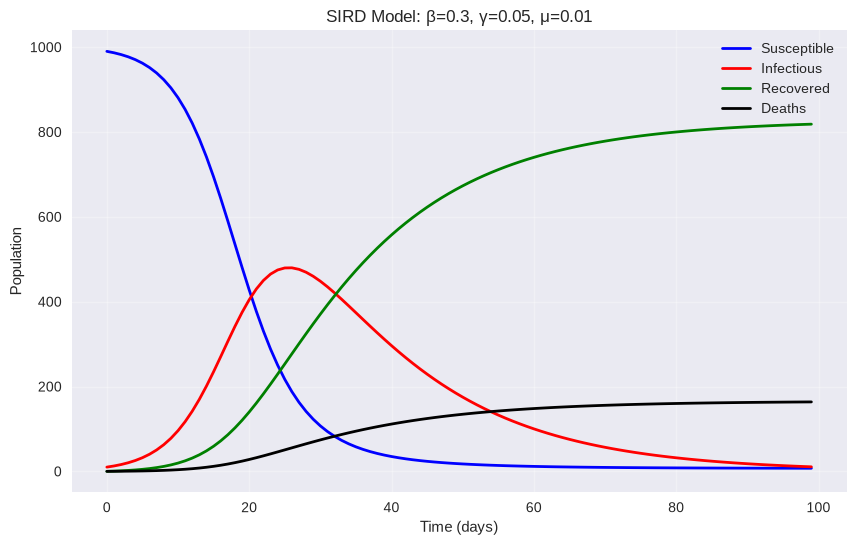

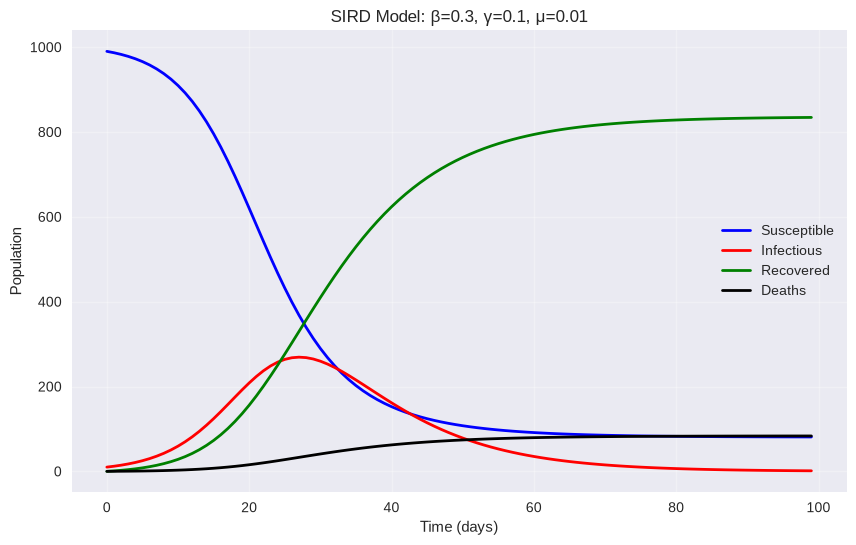

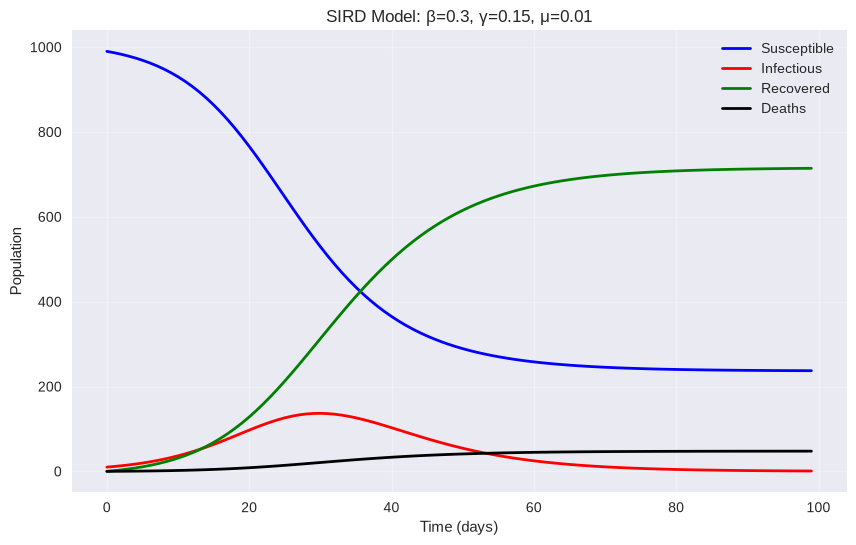

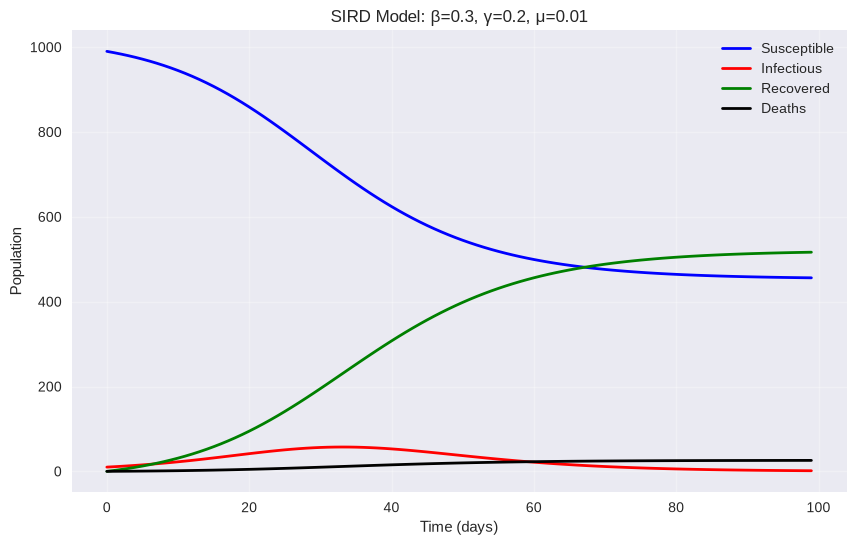

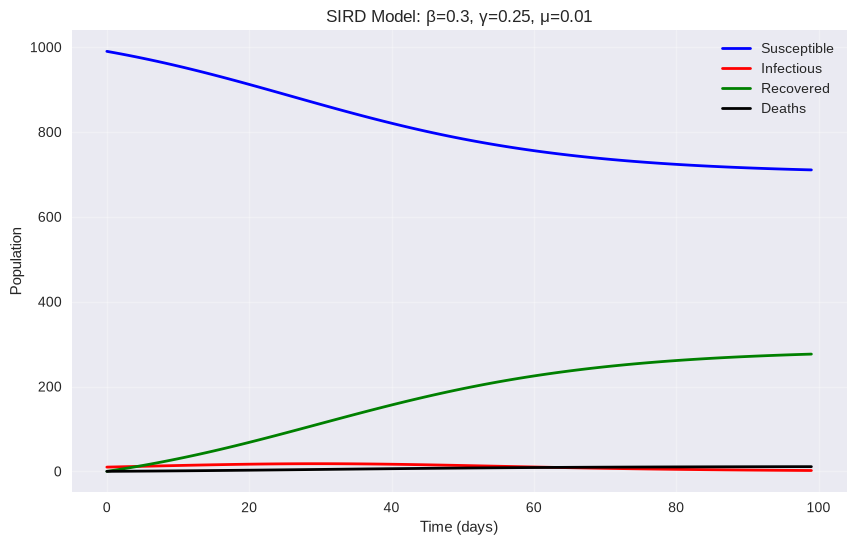

   gamma   R0  peak_infected  peak_day  total_deaths
0   0.05  6.0     479.737984      26.0    163.671765
1   0.10  3.0     269.138176      27.0     83.425371
2   0.15  2.0     136.756407      30.0     47.620529
3   0.20  1.5      57.359889      33.0     25.827702
4   0.25  1.2      18.021355      30.0     11.055013


In [40]:
# print the dataFrame
print(analyze_recovery_rates(0.3, 0.01, display_plots=True))

## Part 2


In [13]:
#Scenario A - "High Transmission":
scenario_a = analyze_recovery_rates(beta=0.4, mu=0.02, N=1000, I0=5, simulation_days=200, display_plots=False)
print(scenario_a)

   gamma        R0  peak_infected  peak_day  total_deaths
0   0.05  8.000000     520.582635      21.0    284.757361
1   0.10  4.000000     340.140583      22.0    159.892366
2   0.15  2.666667     213.465894      24.0    102.610885
3   0.20  2.000000     123.893909      27.0     67.423926
4   0.25  1.600000      63.051893      30.0     42.694003


In [14]:
#Scenario B - "Low Transmission":
scenario_b = analyze_recovery_rates(beta=0.2, mu=0.005, N=1000, I0=5, simulation_days=200, display_plots=False)
print(scenario_b)

   gamma        R0  peak_infected  peak_day  total_deaths
0   0.05  4.000000     371.356334      44.0     88.224137
1   0.10  2.000000     139.333450      52.0     36.699911
2   0.15  1.333333      31.340756      67.0     13.640017
3   0.20  1.000000       5.000000       0.0      1.831032
4   0.25  0.800000       5.000000       0.0      0.433166


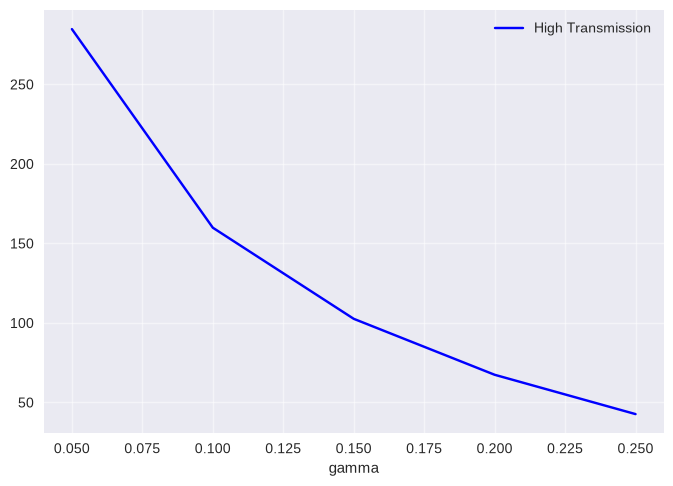

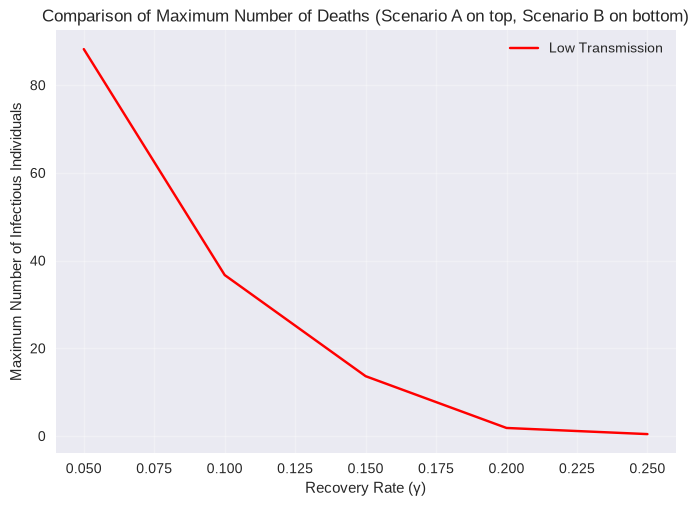

In [15]:
#Comparative side-by-side plot:
comb_plot = scenario_a.plot(x='gamma', y='total_deaths', label='High Transmission', color='blue')
comb_plot = scenario_b.plot(x='gamma', y='total_deaths', label='Low Transmission', color='red')
plt.xlabel('Recovery Rate (γ)')
plt.ylabel('Maximum Number of Infectious Individuals')
plt.title('Comparison of Maximum Number of Deaths (Scenario A on top, Scenario B on bottom)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

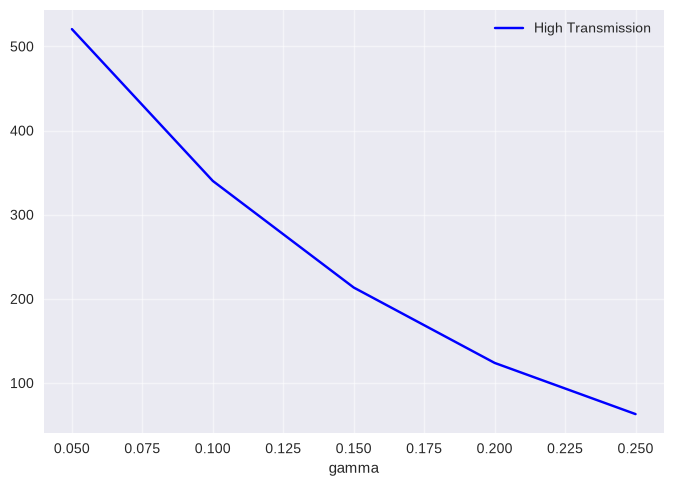

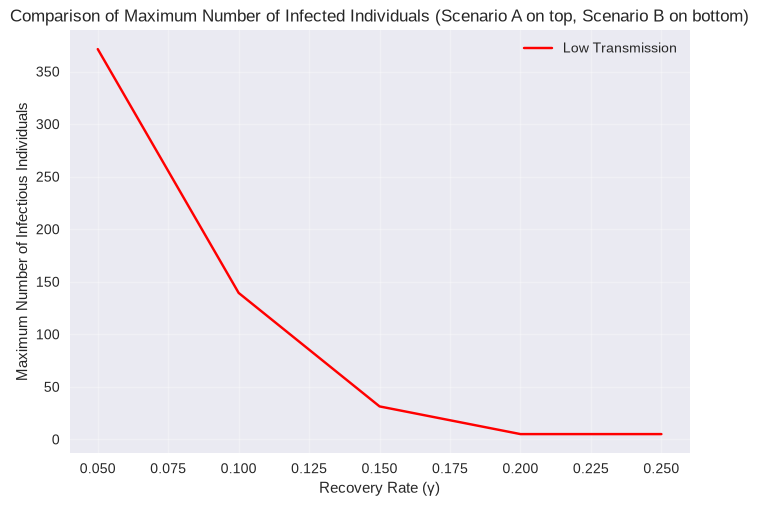

In [16]:
comb_plot = scenario_a.plot(x='gamma', y='peak_infected', label='High Transmission', color='blue')
comb_plot = scenario_b.plot(x='gamma', y='peak_infected', label='Low Transmission', color='red')
plt.xlabel('Recovery Rate (γ)')
plt.ylabel('Maximum Number of Infectious Individuals')
plt.title('Comparison of Maximum Number of Infected Individuals (Scenario A on top, Scenario B on bottom)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Analysis:
As we can see on the plots, scenario B with lower transmission and mortality rates ultimately leads to less deaths, as well as less infected individuals.

DataFrames produced in both scenrarios show a similar picture: lower transmission rate and mortality rate are a much better scenario for the public health.


## Part 3 — Policy Recommendations (20 points)

### 3.1 Parameter impact analysis

### 3.2 Intervention analysis

### 3.3 Real-world application

### 5. Conclusions
